# **Penting**
- Jangan menambahkan import libary atau function apa pun, selain yang sudah tersedia pada cell code.
- Jangan mengubah atau menambahkan cell text yang sudah disediakan, Anda hanya perlu mengerjakan cell code yang sudah disediakan.
- Ingat, tugas Anda hanyalah melengkapi code yang rumpang pada bagian yang sudah ditandai "________" saja.
- Pastikan seluruh kriteria memiliki output yang sesuai, karena jika tidak ada output dianggap tidak selesai.
- Misal, Anda menggunakan df = df.dropna() silakan gunakan df.isnull().sum() sebagai tanda sudah berhasil. Silakan sesuaikan seluruh output dengan perintah yang sudah disediakan.
- Pastikan juga output yang dihasilkan sesuai dengan output yang diharapkan (expected output). Sehingga Anda dapat mereview sendiri terlebih dahulu output dari cell code yang dijalankan.
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Pastikan Anda menggunakan variabel df dari awal sampai akhir dan tidak diperbolehkan mengganti nama variabel tersebut.
- Pastikan Anda mengerjakan sesuai section yang sudah diberikan tanpa mengubah judul atau header yang disediakan.

# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

Tugas kamu adalah membuat model clustering yang selanjutnya akan digunakan untuk membuat model klasifikasi.


# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning. Semua library yang dibutuhkan harus **import** di **cell** ini, jika ada library yang dijalankan di cell lain maka **submission langsung ditolak**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import joblib

# **2. Memuat Dataset**
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook lalu mengecek informasi dataset sebelum nantinya dilakukan pembersihan. Hal-hal yang perlu dilakukan pada tahapan ini yaitu:
1. **Memahami Struktur Data**
   - Dataset harus mengambil referensi wajib digunakan (bisa dilihat [Disini](https://drive.google.com/drive/folders/1Zs7VmPZ-jNwsRlMKH65Ea-LApSwx6lKx?usp=drive_link))
   - Melakukan loading dataset ke dalam notebook dan menampilkan 5 baris pertama dengan function `head`.
   - Tinjau jumlah baris kolom dan jenis data dalam dataset dengan function `info`.  
   - Menampilkan statistik deskriptif dataset dengan menjalankan `describe`.
   - Pastikan **setiap function tersebut** memiliki **output pada setiap cell** code. Jika tidak **submission langsung ditolak**
   

Gunakan code ini untuk melakukan load data secara otomatis tanpa harus download data tersebut secara manual:
```python
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'
df = pd.read_csv(url)
```

Penting: pada kriteria pertama hindari penggunaan print() dan display() karena seluruh fungsi yang digunakan sudah memiliki standar output dan menghasilkan output yang diharapkan.

Kriteria 1 akan ditolak ketika:
- print(__.head())
- display(___.head())
dst

Kriteria 1 akan diterima ketika Anda menggunakan fungsi yang diminta tanpa menambahkan deskripsi apapun.

In [2]:
# Load data

### MULAI CODE ###

url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'
df = pd.read_csv(url)



In [3]:
# Tampilkan 5 baris pertama dengan function head.

### MULAI CODE ###

df.head()



,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39


### **Output yang diharapkan:**

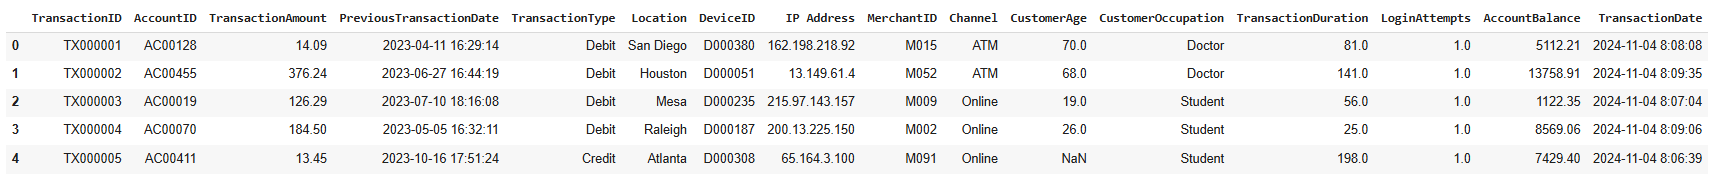

In [4]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.

### MULAI CODE ###

df.info()



<class 'pandas.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   str    
 1   AccountID                2516 non-null   str    
 2   TransactionAmount        2511 non-null   float64
 3   PreviousTransactionDate  2509 non-null   str    
 4   TransactionType          2507 non-null   str    
 5   Location                 2507 non-null   str    
 6   DeviceID                 2507 non-null   str    
 7   IP Address               2517 non-null   str    
 8   MerchantID               2514 non-null   str    
 9   Channel                  2510 non-null   str    
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   str    
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance           2510 non-n

### **Output yang diharapkan:**

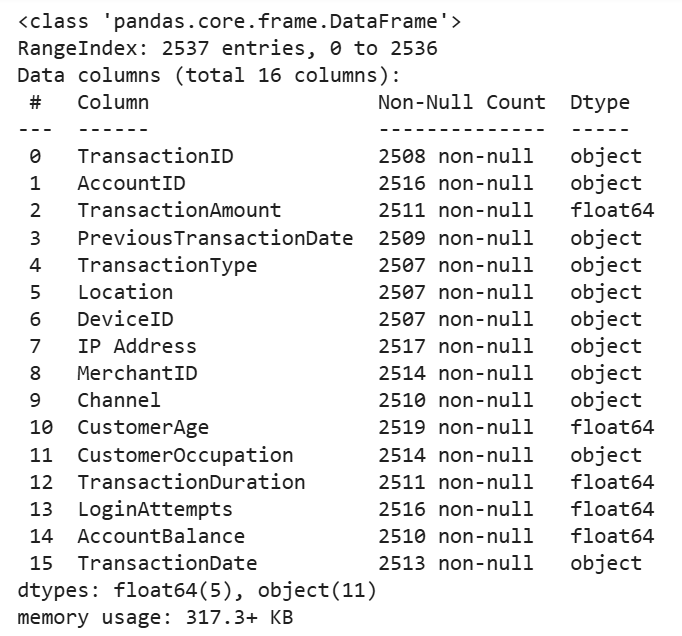

In [5]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe

### MULAI CODE ###

df.describe()



,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

**Apabila ingin menerapkan Advanced, pastikan seluruh visualisasi tidak ada yang overlap**

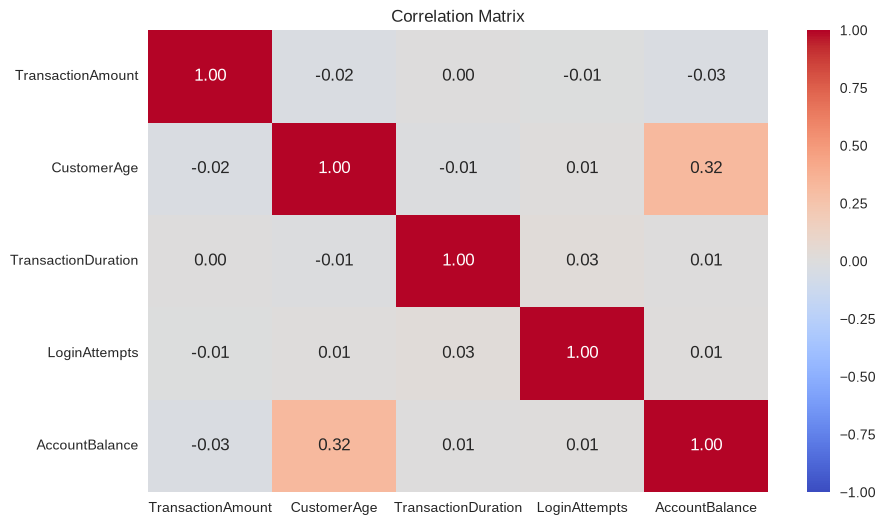

In [6]:
# Menampilkan korelasi antar fitur (Opsional Skilled 1)

# Memilih kolom numerik
numerical_cols = df.select_dtypes(include=['number']).columns

### MULAI CODE ###

# Hitung matriks korelasi
correlation = df[numerical_cols].corr()

# Buat visualisasi heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation,
               annot=True,
               cmap='coolwarm',
               fmt=".2f",
               vmin=-1,
               vmax=1)
plt.title('Correlation Matrix')
plt.show()



## **Output yang diharapkan:**

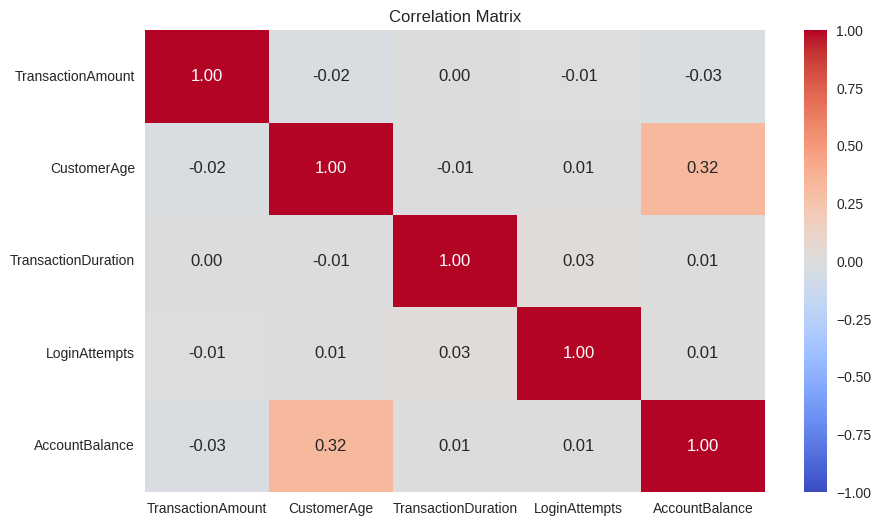

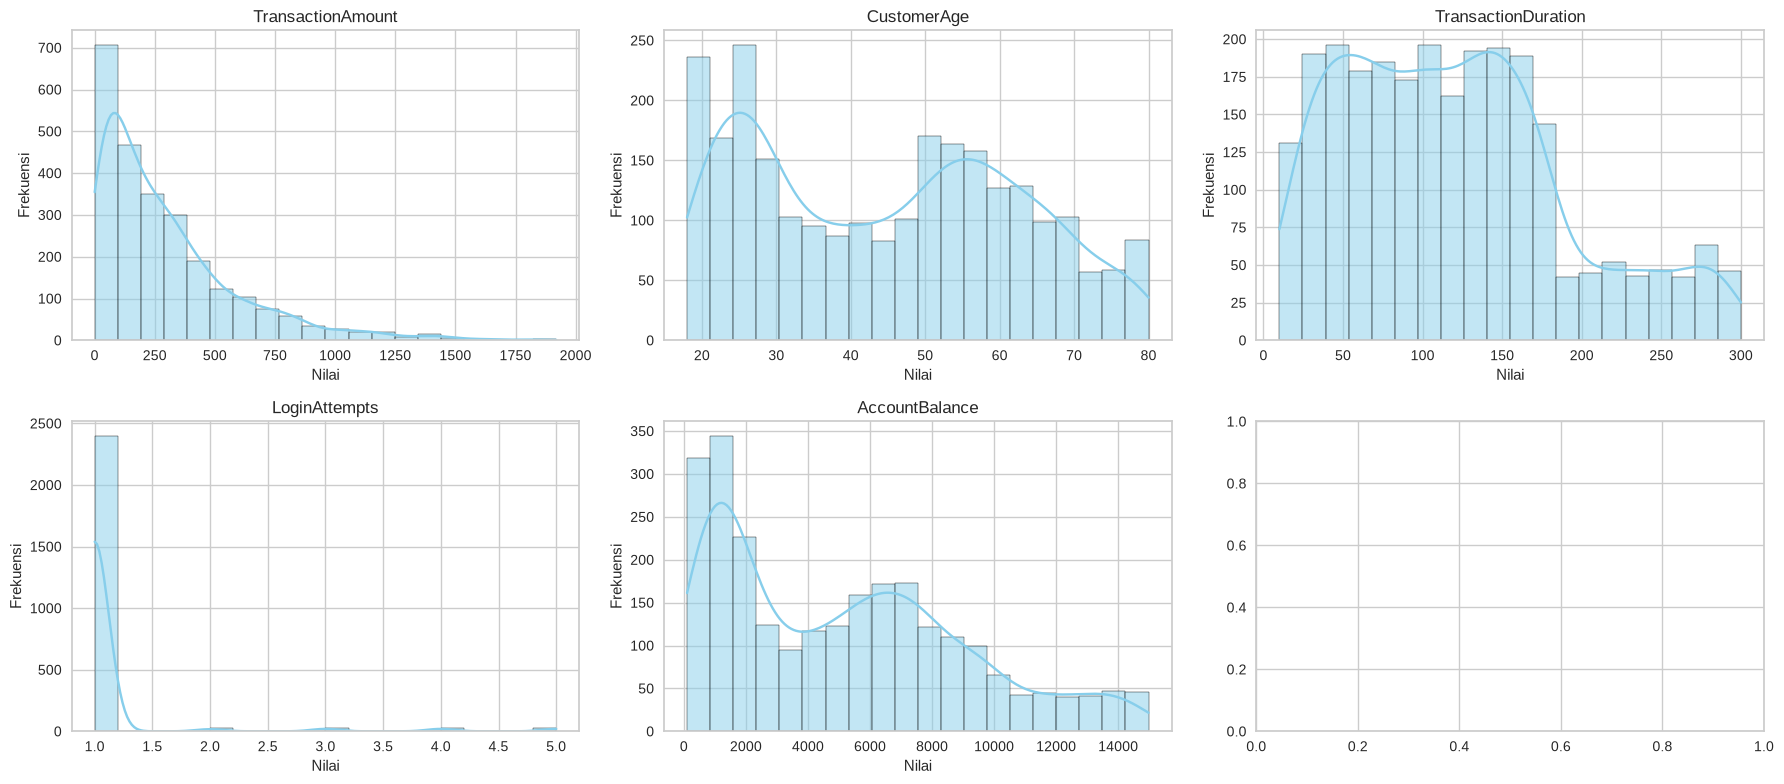

In [7]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, column in enumerate(numerical_cols):

    ### MULAI CODE ###

    # Tampilkan histogram dan pastikan plot ditempatkan di subplot (axes) yang benar
    sns.histplot(df[column], bins=20, kde=True, color='skyblue', ax=axes[i])

    # Atur judul dan label
    axes[i].set_title(column)
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")

    ### SELESAI CODE ###

plt.tight_layout()


## **Output yang diharapkan:**

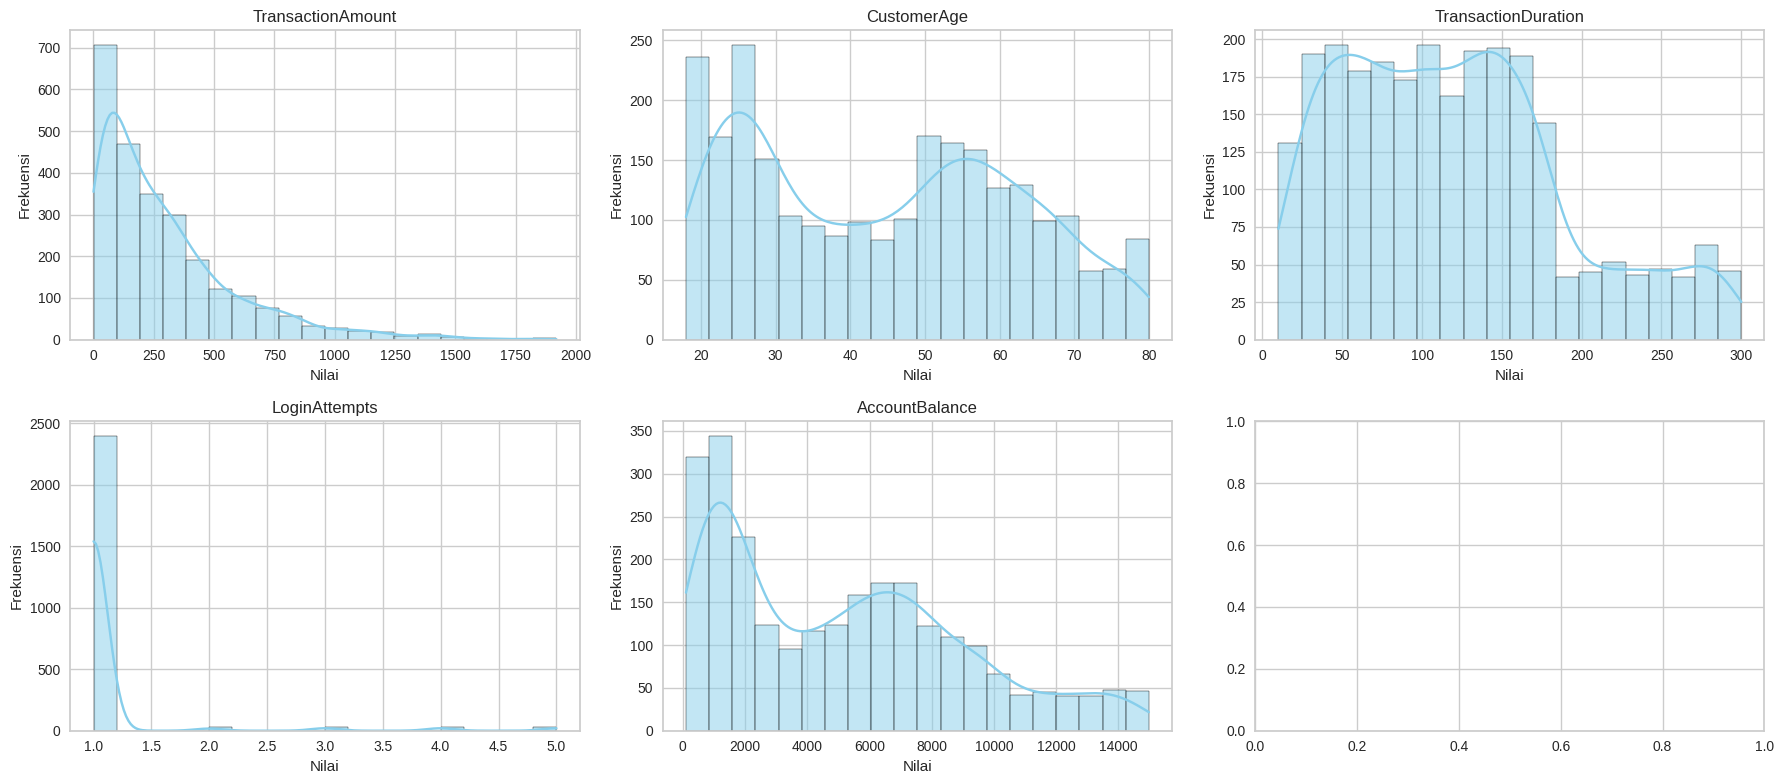

(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

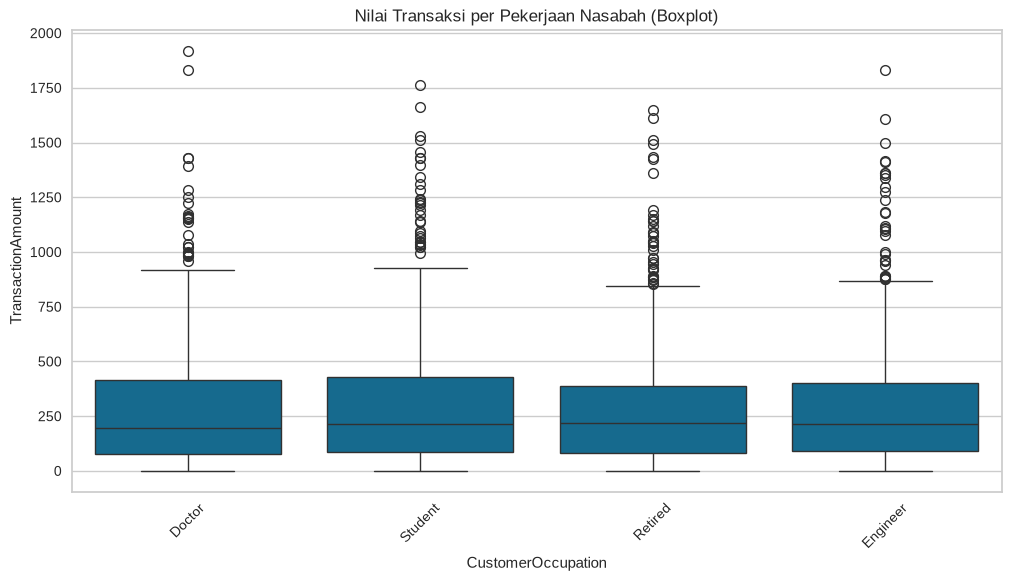

In [8]:
# Visualisasi yang lebih informatif (Opsional Advanced 1)

### MULAI CODE ###

plt.figure(figsize=(12, 6))

# Buat visualisasi boxplot untuk melihat sebaran 'TransactionAmount' (y) berdasarkan 'CustomerOccupation' (x)
sns.boxplot(x='CustomerOccupation', y='TransactionAmount', data=df)

plt.title("Nilai Transaksi per Pekerjaan Nasabah (Boxplot)")

# Putar label sumbu-x agar tidak tumpang tindih
plt.xticks(rotation=45)

plt.show()

### SELESAI CODE ###

# -----------------------------------------------------------------
# (TANTANGAN OPSIONAL)
# -----------------------------------------------------------------
# Sekarang, bagaimana jika kita juga ingin melihat kepadatan distribusi data di setiap kategori?


# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, Anda akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib kamu lakukan yaitu:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan drop pada data null/nan dan data yang duplicate
3. Melakukan drop pada seluruh kolom id, address, dan date.
4. Melakukan feature encoding menggunakan `LabelEncoder()` untuk fitur kategorikal.
5. **Ketentuan Cell Code**
   - Pastikan **setiap pemeriksaan tersebut** memiliki **output pada cell-nya**. Jika tidak **submission langsung ditolak**


In [9]:
# Mengecek dataset menggunakan isnull().sum()

### MULAI CODE ###

df.isnull().sum()



TransactionID              29
AccountID                  21
TransactionAmount          26
PreviousTransactionDate    28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
TransactionDate            24
dtype: int64

## **Output yang diharapkan:**

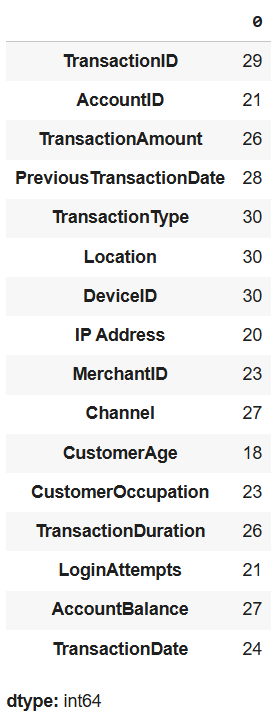

In [10]:
# Mengecek dataset menggunakan duplicated().sum()

### MULAI CODE ###

df.duplicated().sum()



np.int64(21)

## **Output yang diharapkan:**

### np.int64(21)

In [11]:
# Menangani data yang hilang.

### MULAI CODE ###

# Panggil fungsi untuk menghapus baris yang hilang dan pastikan agar perubahan disimpan kembali ke 'df'
df.dropna(inplace=True)

# Cek kembali dataset menggunakan isnull().sum()
df.isnull().sum()



TransactionID              0
AccountID                  0
TransactionAmount          0
PreviousTransactionDate    0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
TransactionDate            0
dtype: int64

## **Output yang diharapkan:**

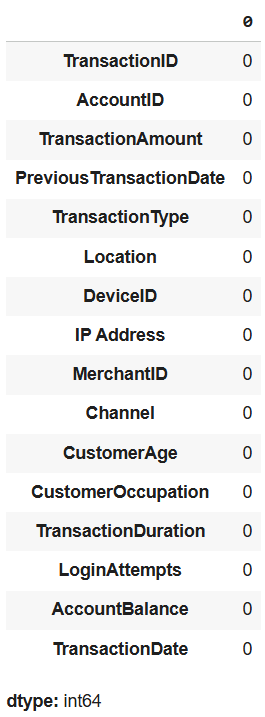

In [12]:
# Menghapus data duplikat.

### MULAI CODE ###

# Panggil fungsi untuk menghapus baris duplikat dan pastikan agar perubahan disimpan kembali ke 'df'
df.drop_duplicates(inplace=True)

# Cek kembali dataset menggunakan duplicated().sum()
df.duplicated().sum()



np.int64(0)

## **Output yang diharapkan:**

### np.int64(0)

In [13]:
# Melakukan drop pada kolom yang memiliki keterangan Date, id, dan IP Address

### MULAI CODE ###

# Buat list comprehension untuk memfilter nama kolom.
#    - Iterasi melalui semua nama kolom (col).
#    - Cek apakah 'id', 'ip', atau 'date' ada di nama kolom.
#    - Gunakan .lower() untuk membuat perbandingan case-insensitive (mengabaikan besar/kecil).

cols_to_drop = [col for col in df.columns if
                'id' in col.lower() or
                'ip' in col.lower() or
                'date' in col.lower()]

# Gunakan fungsi .drop() untuk menghapus kolom-kolom yang ada di 'cols_to_drop'.
df = df.drop(columns=cols_to_drop)

# Tampilkan 5 baris pertama untuk memverifikasi
df.head()



,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06
5,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68


## **Output yang diharapkan:**

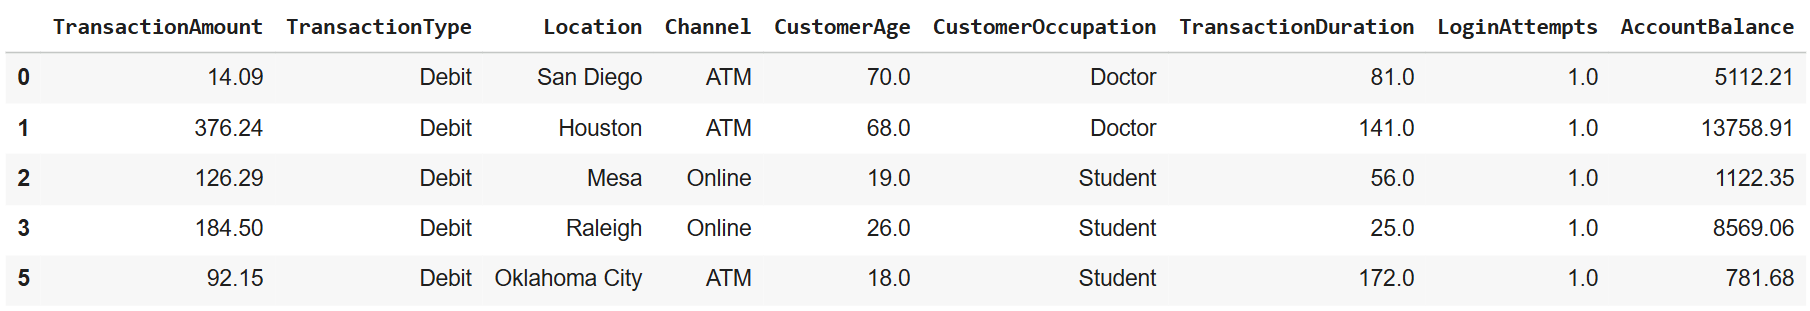

In [14]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.
# Pastikan kamu menggunakan function head setelah melalukan encoding.

### MULAI CODE ###

# Pilih semua kolom yang bertipe 'object' (kategorikal)
categorical_cols = list(df.select_dtypes(include=['object']).columns)

encoders = {}

# Loop melalui setiap kolom kategorikal
for column in categorical_cols:
    # Buat (instantiate) objek LabelEncoder
    label_encoder = LabelEncoder()

    # Terapkan (fit) encoder ke data dan sekaligus ubah (transform) data tersebut
    df[column] = label_encoder.fit_transform(df[column])

    # Simpan encoder
    encoders[column] = label_encoder

# Tampilkan 5 baris pertama untuk memverifikasi hasil encoding
df.head()



/tmp/ipykernel_16648/1745056095.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = list(df.select_dtypes(include=['object']).columns)


,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,1,36,0,70.0,0,81.0,1.0,5112.21
1,376.24,1,15,0,68.0,0,141.0,1.0,13758.91
2,126.29,1,23,2,19.0,3,56.0,1.0,1122.35
3,184.50,1,33,2,26.0,3,25.0,1.0,8569.06
5,92.15,1,28,0,18.0,3,172.0,1.0,781.68


## **Output yang diharapkan:**

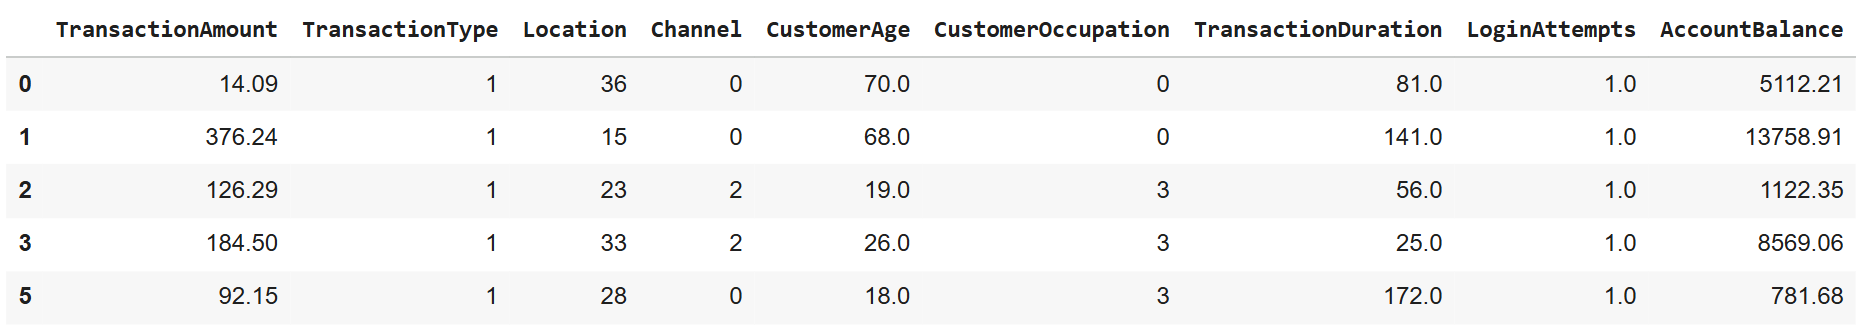

In [15]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.
# Perbaiki kode di bawah ini tanpa menambahkan atau mengurangi cell code ini.

### MULAI CODE ###

df.columns.tolist()



['TransactionAmount',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance']

## **Output yang diharapkan:**

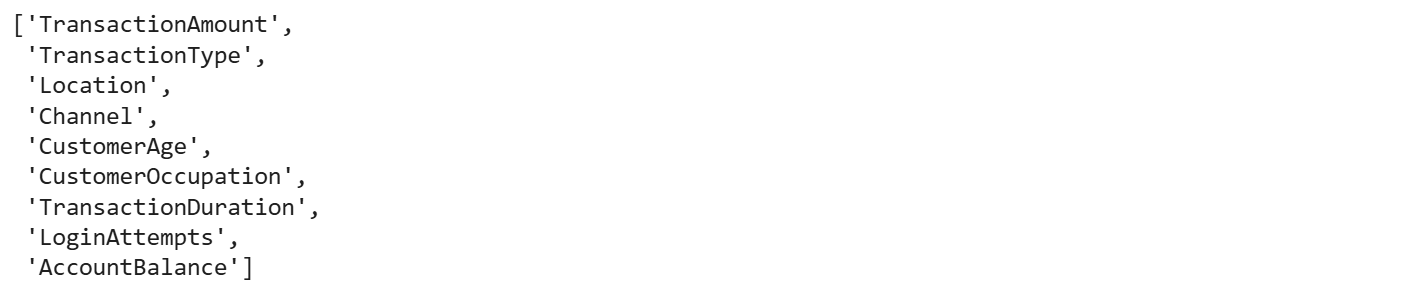

(Opsional) Pembersihan dan Pra Pemrosesan Data [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [16]:
# Melakukan Handling Outlier Data menggunakan metode drop.

for col in numerical_cols:

    ### MULAI CODE ###

    # Hitung Kuartil 1 (Q1) dan Kuartil 3 (Q3)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Hitung Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Tentukan batas bawah (lower bound) dan batas atas (upper bound)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter DataFrame: Simpan hanya baris di mana nilai 'df[col]' berada DI ANTARA (inklusif) batas bawah dan batas atas.
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    ### SELESAI CODE ###

# Tampilkan statistik deskriptif setelah outlier dihapus
df.describe()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
count,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.0,1945.000000
mean,256.838278,0.771722,21.299743,0.977378,44.693059,1.503342,119.225193,1.0,5100.811913
std,218.370197,0.419830,12.329250,0.804119,17.743453,1.135888,70.600647,0.0,3907.153333
min,0.260000,0.000000,0.000000,0.000000,18.000000,0.000000,10.000000,1.0,102.200000
25%,78.920000,1.000000,11.000000,0.000000,27.000000,0.000000,63.000000,1.0,1488.650000
50%,199.700000,1.000000,21.000000,1.000000,45.000000,1.000000,111.000000,1.0,4693.600000
75%,374.500000,1.000000,32.000000,2.000000,59.000000,3.000000,162.000000,1.0,7659.990000
max,903.190000,1.000000,42.000000,2.000000,80.000000,3.000000,300.000000,1.0,14977.990000


## **Output yang diharapkan:**

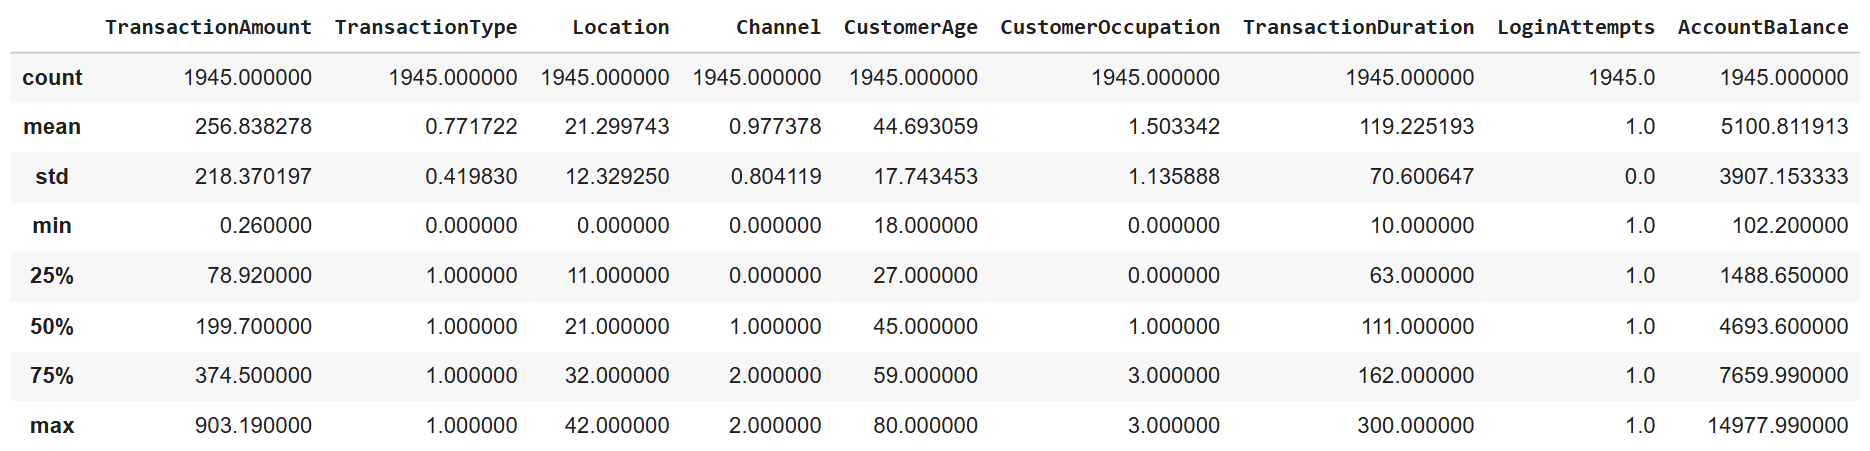

In [17]:
# Melakukan feature scaling menggunakan StandardScaler() untuk fitur numerik.
# Pastikan kamu menggunakan function head setelah melalukan scaling.

### MULAI CODE ###

# Buat (instantiate) StandardScaler
scaler = StandardScaler()

# Terapkan (fit) scaler ke data dan sekaligus ubah (transform) data tersebut
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Tampilkan 5 baris pertama untuk memverifikasi hasil scaling
df.head()



,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,-1.111922,1,36,0,1.426636,0,-0.541568,0.0,0.002918
1,0.546926,1,15,0,1.313889,0,0.308502,0.0,2.216531
2,-0.597984,1,23,2,-1.448403,3,-0.895763,0.0,-1.018513
3,-0.331350,1,33,2,-1.053790,3,-1.334965,0.0,0.887895
5,-0.754364,1,28,0,-1.504776,3,0.747704,0.0,-1.105726


## **Output yang diharapkan:**

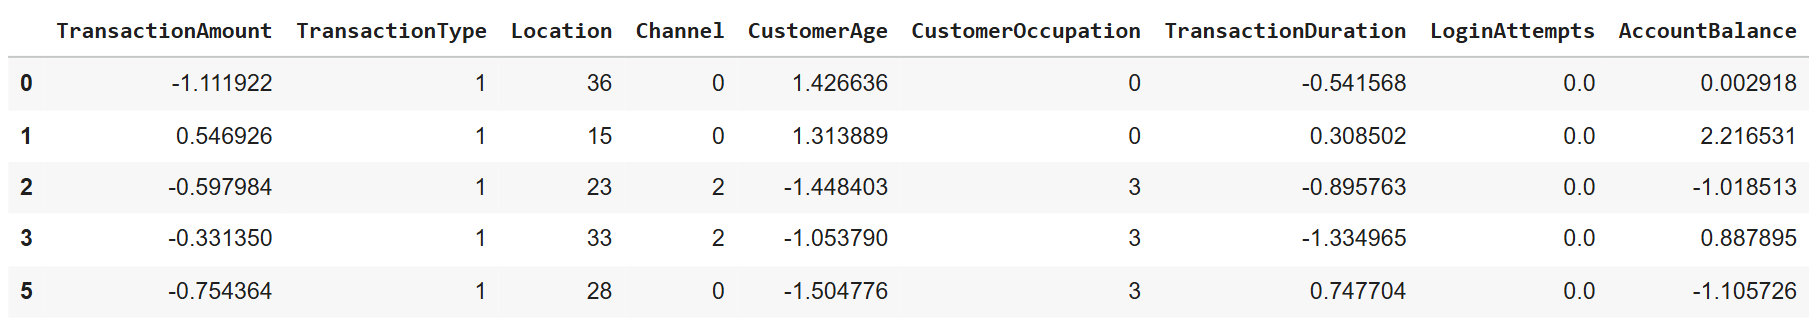

(Opsional) Pembersihan dan Pra Pemrosesan Data [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [18]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# lakukan pada satu sampai dua fitur numerik.
# Silahkan lakukan encode hasil binning tersebut menggunakan LabelEncoder.
# Pastikan kamu mengerjakan tahapan ini pada satu cell.

### MULAI CODE ###

# Tentukan kolom numerik yang ingin Anda kelompokkan
col_to_bin = 'CustomerAge'  # (Isi dengan 'CustomerAge' atau kolom numerik lain)

# Tentukan nama untuk kolom kategori baru
new_col_name = 'AgeGroup'

# Tentukan label untuk 3 grup (Anda dapat menentukan nama label-nya sendiri)
# Mulai dari rendah --> sedang --> tinggi
bin_labels = ['rendah', 'sedang', 'tinggi']

# Gunakan 'pd.qcut' untuk membagi data menjadi 3 kelompok
df[new_col_name] = pd.qcut(df[col_to_bin], q=3, labels=bin_labels, duplicates='drop')

# Lakukan Label Encoding pada kolom baru ini agar menjadi numerik
label_encoder = LabelEncoder()
df[new_col_name] = label_encoder.fit_transform(df[new_col_name])

# Simpan encoder dan tambahkan nama kolom baru ke 'categorical_cols'
encoders[new_col_name] = label_encoder
categorical_cols.extend([new_col_name])

# Tampilkan 5 baris pertama untuk memverifikasi
df.head()



,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,AgeGroup
0,-1.111922,1,36,0,1.426636,0,-0.541568,0.0,0.002918,1
1,0.546926,1,15,0,1.313889,0,0.308502,0.0,2.216531,1
2,-0.597984,1,23,2,-1.448403,3,-0.895763,0.0,-1.018513,2
3,-0.331350,1,33,2,-1.053790,3,-1.334965,0.0,0.887895,2
5,-0.754364,1,28,0,-1.504776,3,0.747704,0.0,-1.105726,2


# **4. Membangun Model Clustering**
Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan.
1. Pastikan Anda menggunakan dataframe yang sudah melalui processing sesuai dengan levelnya (Basic, Skilled, Advanced)
2. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
3. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
4. Jalankan cell code `joblib.dump(model_kmeans, "model_clustering.h5")` untuk menyimpan model yang sudah dibuat.

In [19]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
# Lengkapi kode ini dengan mengubah nama DataFrame yang akan dilatih.
# Kode harus digunakan dan dilarang menambahkan syntax lainnya pada cell ini.

### MULAI CODE ###

# Buat salinan (copy) dari 'df' ke variabel 'df_used'
df_used = df.copy()

# Tampilkan ringkasan statistik dari DataFrame 'df'
df_used.describe()



,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,AgeGroup
count,1.945000e+03,1945.000000,1945.000000,1945.000000,1.945000e+03,1945.000000,1.945000e+03,1945.0,1.945000e+03,1945.000000
mean,-8.402305e-17,0.771722,21.299743,0.977378,-1.269479e-16,1.503342,2.557223e-17,0.0,-6.027740e-17,1.015424
std,1.000257e+00,0.419830,12.329250,0.804119,1.000257e+00,1.135888,1.000257e+00,0.0,1.000257e+00,0.820123
min,-1.175271e+00,0.000000,0.000000,0.000000,-1.504776e+00,0.000000,-1.547483e+00,0.0,-1.279678e+00,0.000000
25%,-8.149648e-01,1.000000,11.000000,0.000000,-9.974163e-01,0.000000,-7.965883e-01,0.0,-9.247374e-01,0.000000
50%,-2.617251e-01,1.000000,21.000000,1.000000,1.730327e-02,1.000000,-1.165330e-01,0.0,-1.042490e-01,1.000000
75%,5.389562e-01,1.000000,32.000000,2.000000,8.065296e-01,3.000000,6.060257e-01,0.0,6.551666e-01,2.000000
max,2.960651e+00,1.000000,42.000000,2.000000,1.990369e+00,3.000000,2.561185e+00,0.0,2.528623e+00,2.000000


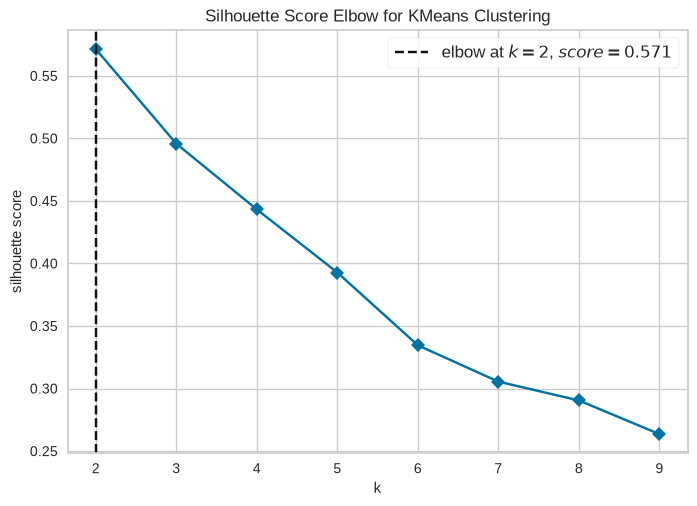

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [20]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()

# Buat (instantiate) model clustering
model = KMeans()

### MULAI CODE ###

# Buat (instantiate) KElbowVisualizer
#  - Masukkan 'model' yang akan digunakan
#  - Tentukan jumlah cluster yang akan diuji (range 2 sampai 10)
#  - Tentukan 'metric' evaluasi
visualizer = KElbowVisualizer(model,
                       k=(2,10),
                       metric='silhouette',
                       timings=False)

# Jalankan (fit) visualizer pada data
visualizer.fit(df)

# Tampilkan plot
visualizer.show()



## **Output yang diharapkan** (bisa saja sedikit berbeda)**:**

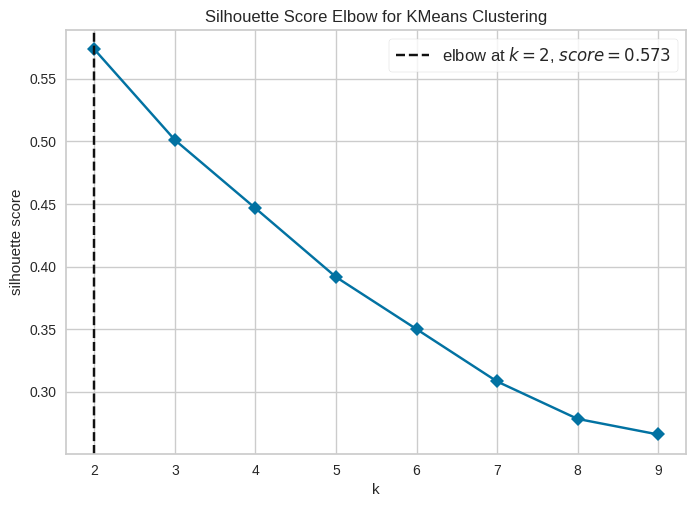

In [21]:
# Menggunakan algoritma K-Means Clustering

### MULAI CODE ###

# Buat (instantiate) objek model KMeans
#  - Tentukan jumlah cluster (n_clusters)
model = KMeans(n_clusters=4, random_state=42)

# Latih (fit) model dengan data Anda (df)
model.fit(df)



,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


Jalankan cell code ini untuk menyimpan model kamu.

In [22]:
# Menyimpan model menggunakan joblib

### MULAI CODE ###

# Simpan model clustering yang sudah dilatih
joblib.dump(model, "model_clustering.h5")



['model_clustering.h5']

(Opsional) Membangun Model Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [23]:
# Menghitung dan menampilkan nilai Silhouette Score.

### MULAI CODE ###

# Dapatkan hasil (label) cluster dari model 'kmeans' yang telah di-fit
labels = model.labels_

# Panggil fungsi untuk menghitung silhouette score
score = silhouette_score(df, labels)

# Cetak skornya
print("Silhouette Score:", score)



Silhouette Score: 0.44240366767165124


/tmp/ipykernel_16648/2371179457.py:19: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(
/home/qura/Documents/Submission/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


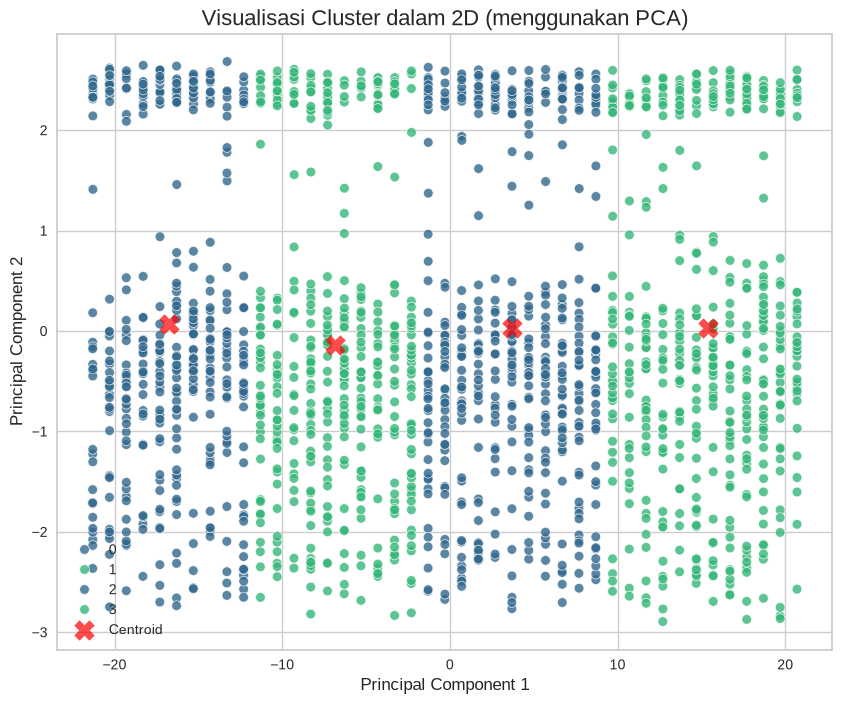

In [24]:
# Membuat visualisasi hasil clustering

### MULAI CODE ###

# Buat (instantiate) objek PCA untuk 2 komponen (n_components=2)
pca = PCA(n_components=2)

# Terapkan (fit) PCA ke data 'df' dan transformasikan data tersebut
df_pca = pca.fit_transform(df)

# Buat DataFrame baru 'df_pca' dari hasil transformasi
df_pca = pd.DataFrame(data=df_pca, columns=['Principal Component 1', 'Principal Component 2'])

# Tambahkan kolom 'Cluster' ke 'df_pca' menggunakan 'labels'(variabel dari hasil 'kmeans.labels_' sebelumnya)
df_pca['Cluster'] = labels

# Buat scatter plot menggunakan Seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',  # Warnai titik berdasarkan kolom 'Cluster'
    palette=sns.color_palette("viridis", n_colors=2),
    data=df_pca,
    legend="full",
    alpha=0.8
)

### SELESAI CODE ###

plt.title('Visualisasi Cluster dalam 2D (menggunakan PCA)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
centers = pca.transform(model.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.7, marker='X', label='Centroid')
plt.legend()


## **Output yang diharapkan** (bisa saja sedikit berbeda)**:**

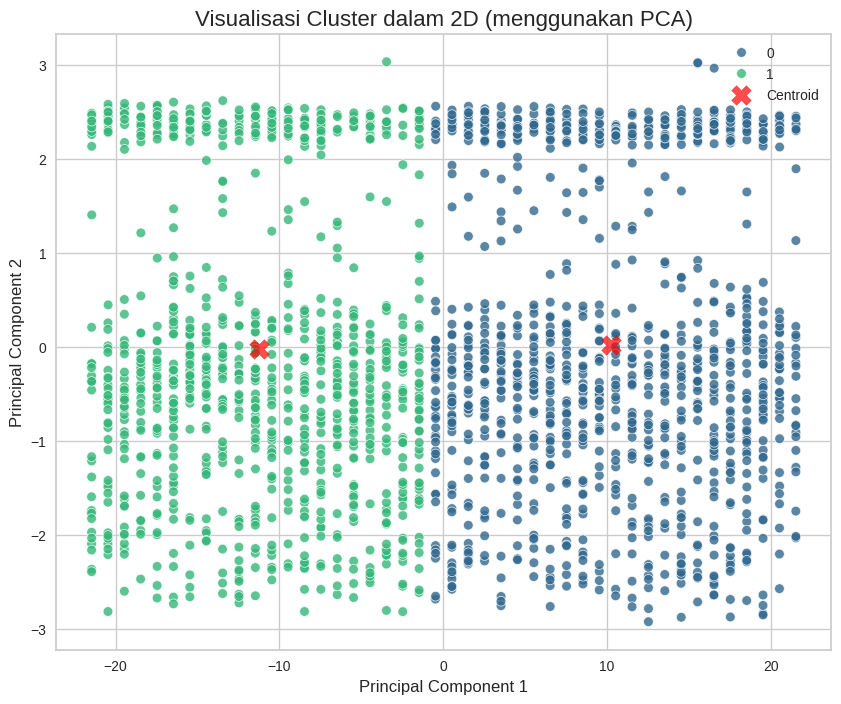

(Opsional) Membangun Model Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [25]:
# Membangun model menggunakan PCA.

### MULAI CODE ###

# Buat (instantiate) objek PCA dengan 2 komponen
pca = PCA(n_components=2)

# Terapkan (fit) PCA ke data 'df_used' dan transformasikan data tersebut
df_pca_array = pca.fit_transform(df_used)

# Buat DataFrame baru 'data_final' dari hasil array PCA
data_final = pd.DataFrame(data=df_pca_array, columns=['PCA1', 'PCA2'])

# Buat (instantiate) model KMeans BARU
kmeans_pca = KMeans(n_clusters=4, random_state=42)

# Latih (fit) model KMeans BARU ini HANYA pada 'data_final'
kmeans_pca.fit(data_final)



,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [26]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")

### MULAI CODE ###

# Pastikan yang disimpan model yang sudah melalui .fit berdasarkan dataset yang sudah dilakukan PCA
joblib.dump(kmeans_pca, "PCA_model_clustering.h5")



['PCA_model_clustering.h5']

# **5. Interpretasi Cluster**

## **a. Interpretasi Hasil Clustering**
1. **Contoh Interpretasi:**
- **Cluster 1: (Nasabah Bertransaksi dan Pendapatan Besar)**:
  - **Rata-rata (mean) Transaction Amount:** -0.01
  - **Rata-rata (mean) Customer Age:** 0.32
  - **Analisis:** Cluster ini mencakup pelanggan usia lanjut usia dengan jumlah transaksi yang dilakukan cukup rendah. Pelanggan dalam cluster ini cenderung memiliki daya beli yang rendah dan cenderung bermain aman. Sehingga rekomendasi pada kelompok nasabah ini adalah dengan menawarkan produk-produk investasi atau perbankan dengan resiko rendah.


In [27]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
# Silakan menambahkan fungsi agregasi lainnya untuk experience lebih baik.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max.

### MULAI CODE ###

# Tambahkan kolom 'Cluster' baru berupa 'labels' (variabel dari 'kmeans.labels_' sebelumnya)
df_used['Cluster'] = labels

# Kelompokkan (groupby) 'df_used' berdasarkan 'Cluster' dan hitung agregasi untuk 'numerical_cols'.
df_used.groupby('Cluster')[numerical_cols].agg(['mean', 'min', 'max'])

TransactionAmount             CustomerAge             TransactionDuration             LoginAttempts             AccountBalance            
                     mean   min   max        mean   min   max                mean   min   max          mean  min  max           mean   min   max
Cluster                                                                                                                                           
0                   -0.01 -1.17  2.93        0.03 -1.50  1.99                0.02 -1.55  2.56           0.0  0.0  0.0          -0.00 -1.27  2.52
1                    0.02 -1.17  2.90       -0.07 -1.50  1.99               -0.05 -1.55  2.50           0.0  0.0  0.0          -0.01 -1.28  2.53
2                   -0.03 -1.18  2.84        0.01 -1.50  1.99               -0.00 -1.55  2.55           0.0  0.0  0.0          -0.02 -1.28  2.45
3                    0.02 -1.17  2.96        0.04 -1.50  1.99                0.05 -1.55  2.55           0.0  0.0  0.0           0.04 -1.28  2.52

# **PERHATIAN: JAWAB DI BAWAH SINI**
## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya sebelum **Inverse** (masih dalam kondisi **Scaled**).

Berdasarkan tabel hasil agregasi statistik deskriptif di atas, berikut adalah interpretasi karakteristik setiap cluster yang mencantumkan nilai **Rata-rata (mean)**, **Minimum (min)**, dan **Maksimum (max)** untuk seluruh fitur numerik beserta analisis profil nasabah dan rekomendasi bisnis perbankan:

---

### 1. Cluster 0: (Nasabah Konvensional Usia Menengah - Transaksi Harian Standar)
* **Statistik Fitur Numerik (Scaled Data):**
  - **Rata-rata (mean) Transaction Amount:** -0.01 | **Min:** -1.17 | **Max:** 2.93
  - **Rata-rata (mean) Customer Age:** 0.03 | **Min:** -1.50 | **Max:** 1.99
  - **Rata-rata (mean) Transaction Duration:** 0.02 | **Min:** -1.55 | **Max:** 2.56
  - **Rata-rata (mean) Login Attempts:** 0.00 | **Min:** 0.00 | **Max:** 0.00
  - **Rata-rata (mean) Account Balance:** -0.00 | **Min:** -1.27 | **Max:** 2.52
* **Analisis Karakteristik:**
  Cluster 0 merepresentasikan kelompok nasabah tipikal dengan profil finansial yang sangat seimbang mendekati rata-rata populasi (mean z-score mendekati 0.00 pada Transaction Amount dan Account Balance). Usia nasabah sedikit di atas rata-rata populasi (mean 0.03) dengan durasi transaksi yang normal (mean 0.02). Kelompok ini menggunakan rekening perbankan untuk transaksi rutin kebutuhan sehari-hari tanpa deviasi pengeluaran yang ekstrem. Rentang nilai transaksi (min -1.17 hingga max 2.93) mencerminkan adanya variasi kebutuhan transaksi dari skala kecil hingga menengah ke atas.
* **Rekomendasi Bisnis:**
  Direkomendasikan penawaran produk tabungan berjangka reguler dengan autodebet bulanan, program loyalitas poin reward transaksi belanja rutin harian (groceries/utilitas), serta sosialisasi fitur digital banking untuk meningkatkan retensi dan kemudahan transaksi rutin tanpa antre di kantor cabang.

---

### 2. Cluster 1: (Nasabah Usia Muda Dinamis - Transaksi Cepat & Nominal Aktif)
* **Statistik Fitur Numerik (Scaled Data):**
  - **Rata-rata (mean) Transaction Amount:** 0.02 | **Min:** -1.17 | **Max:** 2.90
  - **Rata-rata (mean) Customer Age:** -0.07 | **Min:** -1.50 | **Max:** 1.99
  - **Rata-rata (mean) Transaction Duration:** -0.05 | **Min:** -1.55 | **Max:** 2.50
  - **Rata-rata (mean) Login Attempts:** 0.00 | **Min:** 0.00 | **Max:** 0.00
  - **Rata-rata (mean) Account Balance:** -0.01 | **Min:** -1.28 | **Max:** 2.53
* **Analisis Karakteristik:**
  Cluster 1 memiliki keunikan berupa rata-rata usia paling muda di antara seluruh kelompok (mean usia -0.07) dan durasi penyelesaian transaksi paling singkat/cepat (mean durasi -0.05). Meskipun saldo tabungan rata-rata mereka sedikit di bawah garis tengah populasi (mean balance -0.01), rata-rata nominal transaksi mereka justru berada di atas rata-rata (mean transaksi 0.02). Hal ini mencirikan segmen generasi muda/pelajar/pekerja awal yang melek teknologi (*tech-savvy*), gesit bertransaksi, dan konsumtif aktif dalam berbelanja.
* **Rekomendasi Bisnis:**
  Fokus strategi adalah kemudahan integrasi pembayaran digital via QRIS dan e-wallet top-up, kolaborasi promo diskon merchant gaya hidup, hiburan, platform streaming, dan e-commerce, serta penyediaan fasilitas micro-financing atau cicilan berbunga rendah (*buy now pay later*) yang terintegrasi di mobile app.

---

### 3. Cluster 2: (Nasabah Konservatif - Saldo Rendah & Transaksi Paling Terbatas)
* **Statistik Fitur Numerik (Scaled Data):**
  - **Rata-rata (mean) Transaction Amount:** -0.03 | **Min:** -1.18 | **Max:** 2.84
  - **Rata-rata (mean) Customer Age:** 0.01 | **Min:** -1.50 | **Max:** 1.99
  - **Rata-rata (mean) Transaction Duration:** -0.00 | **Min:** -1.55 | **Max:** 2.55
  - **Rata-rata (mean) Login Attempts:** 0.00 | **Min:** 0.00 | **Max:** 0.00
  - **Rata-rata (mean) Account Balance:** -0.02 | **Min:** -1.28 | **Max:** 2.45
* **Analisis Karakteristik:**
  Cluster 2 ditandai dengan rata-rata nominal transaksi paling rendah di antara seluruh cluster (mean -0.03 dengan max transaksi terendah 2.84) serta rata-rata saldo rekening paling rendah (mean -0.02 dengan max saldo terendah 2.45). Rata-rata usia nasabah mendekati nilai tengah populasi (mean 0.01) dengan durasi transaksi normal (mean -0.00). Karakteristik ini memperlihatkan segmen nasabah yang memiliki daya beli terbatas atau sangat berhati-hati (konservatif) dalam menggunakan dan menyimpan uangnya di bank.
* **Rekomendasi Bisnis:**
  Pendekatan yang tepat adalah penyediaan produk rekening tabungan dasar tanpa biaya administrasi bulanan (*basic saving account* / tabunganKu), insentif menabung receh berhadiah (*round-up savings*), serta penyuluhan literasi keuangan dan edukasi instrumen investasi mikro berisiko rendah seperti reksadana pasar uang untuk membantu menumbuhkan likuiditas tabungan mereka.

---

### 4. Cluster 3: (Nasabah Profesional Mapan - Saldo Tertinggi & Nilai Transaksi Besar)
* **Statistik Fitur Numerik (Scaled Data):**
  - **Rata-rata (mean) Transaction Amount:** 0.02 | **Min:** -1.17 | **Max:** 2.96
  - **Rata-rata (mean) Customer Age:** 0.04 | **Min:** -1.50 | **Max:** 1.99
  - **Rata-rata (mean) Transaction Duration:** 0.05 | **Min:** -1.55 | **Max:** 2.55
  - **Rata-rata (mean) Login Attempts:** 0.00 | **Min:** 0.00 | **Max:** 0.00
  - **Rata-rata (mean) Account Balance:** 0.04 | **Min:** -1.28 | **Max:** 2.52
* **Analisis Karakteristik:**
  Cluster 3 merupakan segmen nasabah premium (*high-value / affluent*). Kelompok ini memiliki saldo rekening rata-rata tertinggi (mean 0.04), nominal transaksi rata-rata tinggi dengan nilai batas maksimum transaksi terbesar di antara seluruh cluster (mean 0.02, max 2.96), durasi transaksi paling lama dan teliti (mean 0.05), serta usia rata-rata paling matang (mean 0.04). Profil ini mencerminkan nasabah profesional atau wirausahawan mapan yang mengelola perputaran dana bernilai besar dengan stabilitas finansial tinggi.
* **Rekomendasi Bisnis:**
  Prioritaskan segmen ini untuk layanan perbankan prioritas (*Priority / Wealth Management*), produk investasi pasar modal dan obligasi negara (SBR/ORI), penempatan deposito berjangka berbunga khusus, kartu kredit premium tier Platinum/World dengan fasilitas airport lounge, serta fasilitas asuransi proteksi aset dan kesehatan keluarga.

---

### Ringkasan Tabel Perbandingan Metrik Statistik Antar Cluster (Scaled Data):

| Fitur Numerik | Metrik | Cluster 0 | Cluster 1 | Cluster 2 | Cluster 3 | Kesimpulan Komparatif |
| :--- | :--- | :---: | :---: | :---: | :---: | :--- |
| **TransactionAmount** | Mean<br>Min<br>Max | -0.01<br>-1.17<br>2.93 | 0.02<br>-1.17<br>2.90 | -0.03<br>-1.18<br>2.84 | 0.02<br>-1.17<br>2.96 | Cluster 2 nominal transaksi terendah (-0.03); Cluster 3 batas transaksi maksimal tertinggi (2.96). |
| **CustomerAge** | Mean<br>Min<br>Max | 0.03<br>-1.50<br>1.99 | -0.07<br>-1.50<br>1.99 | 0.01<br>-1.50<br>1.99 | 0.04<br>-1.50<br>1.99 | Cluster 1 usia paling muda (-0.07); Cluster 3 usia paling matang/dewasa (0.04). |
| **TransactionDuration** | Mean<br>Min<br>Max | 0.02<br>-1.55<br>2.56 | -0.05<br>-1.55<br>2.50 | -0.00<br>-1.55<br>2.55 | 0.05<br>-1.55<br>2.55 | Cluster 1 durasi paling singkat/gesit (-0.05); Cluster 3 durasi paling lama/teliti (0.05). |
| **LoginAttempts** | Mean<br>Min<br>Max | 0.00<br>0.00<br>0.00 | 0.00<br>0.00<br>0.00 | 0.00<br>0.00<br>0.00 | 0.00<br>0.00<br>0.00 | Konstan pada 1.0 (mean 0.00 setelah standardisasi) di seluruh cluster. |
| **AccountBalance** | Mean<br>Min<br>Max | -0.00<br>-1.27<br>2.52 | -0.01<br>-1.28<br>2.53 | -0.02<br>-1.28<br>2.45 | 0.04<br>-1.28<br>2.52 | Cluster 3 saldo simpanan tertinggi (0.04); Cluster 2 saldo simpanan terendah (-0.02). |


# **6. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [28]:
# Pastikan nama kolom clustering sudah diubah menjadi Target

### MULAI CODE ###

df_used.rename(columns={"Cluster": "Target"}, inplace=True)

# Tampilkan 5 baris pertama untuk memverifikasi
df_used.head()



,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,AgeGroup,Target
0,-1.111922,1,36,0,1.426636,0,-0.541568,0.0,0.002918,1,1
1,0.546926,1,15,0,1.313889,0,0.308502,0.0,2.216531,1,3
2,-0.597984,1,23,2,-1.448403,3,-0.895763,0.0,-1.018513,2,2
3,-0.331350,1,33,2,-1.053790,3,-1.334965,0.0,0.887895,2,1
5,-0.754364,1,28,0,-1.504776,3,0.747704,0.0,-1.105726,2,2


In [29]:
# Simpan Data

### MULAI CODE ###

df_used.to_csv('data_clustering.csv', index=False)



(Opsional) Interpretasi Hasil Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [30]:
# inverse dataset ke rentang normal untuk numerikal

df_inverse = df_used.copy()

### MULAI CODE ###

# Gunakan 'scaler' untuk mengembalikan 'numerical_cols' ke nilai aslinya.
df_inverse[numerical_cols] = scaler.inverse_transform(df_inverse[numerical_cols])

# Tampilkan 5 baris pertama untuk memverifikasi hasilnya
df_inverse.head()



,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,AgeGroup,Target
0,14.09,1,36,0,70.0,0,81.0,1.0,5112.21,1,1
1,376.24,1,15,0,68.0,0,141.0,1.0,13758.91,1,3
2,126.29,1,23,2,19.0,3,56.0,1.0,1122.35,2,2
3,184.50,1,33,2,26.0,3,25.0,1.0,8569.06,2,1
5,92.15,1,28,0,18.0,3,172.0,1.0,781.68,2,2


In [31]:
# inverse dataset yang sudah diencode ke kategori aslinya.

### MULAI CODE ###

for column in categorical_cols:
    # Ambil encoder yang tepat untuk 'column' dari dictionary 'encoders'
    encoder = encoders[column]

    # Gunakan scaler untuk mengembalikan (inverse) kolom tersebut
    df_inverse[column] = encoder.inverse_transform(df_inverse[column].astype(int))

# Tampilkan 5 baris pertama untuk memverifikasi hasilnya
df_inverse.head()



,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,AgeGroup,Target
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,Senior,1
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,Senior,3
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,Young,2
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,Young,1
5,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,Young,2


In [32]:
# Lakukan analisis deskriptif minimal mean, min dan max untuk fitur numerik dan mode untuk kategorikal seperti pada basic tetapi menggunakan data yang sudah diinverse.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max kembali setelah melakukan inverse.

### MULAI CODE ###

# Kelompokkan (groupby) 'df_inverse' berdasarkan 'Target' dan hitung agregasi untuk 'numerical_cols'.
agg_summary_num = df_inverse.groupby('Target')[numerical_cols].agg(['mean', 'min', 'max']).round(2).T

# Kelompokkan (groupby) 'df_inverse' berdasarkan 'Target' dan hitung agregasi untuk 'categorical_cols'.
#   - Hitung agregasi (agg) 'mode' (nilai yang paling sering muncul).
#   - (Kita gunakan 'lambda x: x.mode()[0]' untuk mengambil nilai mode pertama)
agg_summary_cat = df_inverse.groupby('Target')[categorical_cols].agg(lambda x: x.mode()[0]).T

### SELESAI CODE ###

# Tampilkan kedua hasil ringkasan
display(agg_summary_num)
display(agg_summary_cat)


Target                           0         1         2         3
TransactionAmount   mean    254.45    261.40    249.76    261.76
                    min       0.32      1.41      0.26      0.45
                    max     896.79    889.01    877.81    903.19
CustomerAge         mean     45.24     43.50     44.93     45.33
                    min      18.00     18.00     18.00     18.00
                    max      80.00     80.00     80.00     80.00
TransactionDuration mean    120.75    115.42    119.08    122.49
                    min      10.00     10.00     10.00     10.00
                    max     300.00    296.00    299.00    299.00
LoginAttempts       mean      1.00      1.00      1.00      1.00
                    min       1.00      1.00      1.00      1.00
                    max       1.00      1.00      1.00      1.00
AccountBalance      mean   5084.33   5059.76   5024.62   5252.66
                    min     129.29    102.20    112.76    117.98
                    max   14935.50  14977.99  14676.05  14942.78

# **PERHATIAN: JAWAB DI BAWAH SINI**
## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya setelah **Inverse**.

Berdasarkan hasil analisis agregasi statistik deskriptif setelah dilakukan proses **Inverse Transform** (mengembalikan fitur numerik ke skala nominal asli dan fitur kategorikal ke label aslinya), berikut adalah karakteristik mendalam untuk masing-masing cluster:

---

### 1. Cluster 0: Mahasiswa Pengguna Cabang - Transaksi Standar
* **Statistik Fitur Numerik (Inverse Data):**
  - **Rata-rata (mean) Transaction Amount:** $254.45 | **Min:** $0.32 | **Max:** $896.79
  - **Rata-rata (mean) Customer Age:** 45.24 tahun | **Min:** 18.00 tahun | **Max:** 80.00 tahun
  - **Rata-rata (mean) Transaction Duration:** 120.75 detik | **Min:** 10.00 detik | **Max:** 300.00 detik
  - **Rata-rata (mean) Login Attempts:** 1.00 kali | **Min:** 1.00 kali | **Max:** 1.00 kali
  - **Rata-rata (mean) Account Balance:** $5,084.33 | **Min:** $129.29 | **Max:** $14,935.50
* **Kategori Dominan (Mode):**
  - **Channel:** Kantor Cabang (*Branch*)
  - **Pekerjaan:** Mahasiswa (*Student*)
  - **Kelompok Usia (AgeGroup):** *rendah*
  - **Lokasi:** Charlotte
  - **Tipe Transaksi:** Debit
* **Analisis Karakteristik:**
  Cluster 0 merepresentasikan kelompok nasabah dengan aktivitas transaksi dan saldo rekening di kisaran moderat/rata-rata ($5,084.33 dan nominal transaksi $254.45). Nasabah di kelompok ini cenderung melakukan transaksi tatap muka langsung di kantor cabang dengan durasi interaksi layanan sekitar 2 menit (120.75 detik).
* **Rekomendasi Bisnis:**
  Mendorong migrasi transaksi rutin ke mobile banking melalui insentif bebas biaya transfer dan promo loyalitas, serta menawarkan produk asuransi mikro dan tabungan berjangka.

---

### 2. Cluster 1: Nasabah Muda Transaksi Cepat - Belanja Aktif
* **Statistik Fitur Numerik (Inverse Data):**
  - **Rata-rata (mean) Transaction Amount:** $261.40 | **Min:** $0.41 | **Max:** $889.01
  - **Rata-rata (mean) Customer Age:** 43.50 tahun | **Min:** 18.00 tahun | **Max:** 80.00 tahun
  - **Rata-rata (mean) Transaction Duration:** 115.42 detik | **Min:** 10.00 detik | **Max:** 296.00 detik
  - **Rata-rata (mean) Login Attempts:** 1.00 kali | **Min:** 1.00 kali | **Max:** 1.00 kali
  - **Rata-rata (mean) Account Balance:** $5,059.76 | **Min:** $102.20 | **Max:** $14,977.99
* **Kategori Dominan (Mode):**
  - **Channel:** Kantor Cabang (*Branch*)
  - **Pekerjaan:** Mahasiswa (*Student*)
  - **Kelompok Usia (AgeGroup):** *rendah*
  - **Lokasi:** Tucson
  - **Tipe Transaksi:** Debit
* **Analisis Karakteristik:**
  Cluster 1 memiliki rata-rata usia paling muda (43.50 tahun) dan durasi transaksi paling efisien dan cepat (115.42 detik). Meskipun saldo tabungannya sedikit di bawah rata-rata populasi ($5,059.76), rata-rata pengeluaran transaksi mereka relatif tinggi ($261.40). Ini mencerminkan nasabah usia muda yang berbelanja aktif dan mengutamakan kecepatan interaksi.
* **Rekomendasi Bisnis:**
  Menyediakan promo belanja digital merchant lifestyle, kuliner, dan hiburan, fitur autodebet e-wallet, serta produk pembiayaan mikro berbasis digital.

---

### 3. Cluster 2: Nasabah Konservatif - Saldo Terendah & Pengeluaran Terbatas
* **Statistik Fitur Numerik (Inverse Data):**
  - **Rata-rata (mean) Transaction Amount:** $249.76 | **Min:** $0.26 | **Max:** $877.81
  - **Rata-rata (mean) Customer Age:** 44.93 tahun | **Min:** 18.00 tahun | **Max:** 80.00 tahun
  - **Rata-rata (mean) Transaction Duration:** 119.08 detik | **Min:** 10.00 detik | **Max:** 299.00 detik
  - **Rata-rata (mean) Login Attempts:** 1.00 kali | **Min:** 1.00 kali | **Max:** 1.00 kali
  - **Rata-rata (mean) Account Balance:** $5,024.62 | **Min:** $112.76 | **Max:** $14,676.05
* **Kategori Dominan (Mode):**
  - **Channel:** Kantor Cabang (*Branch*)
  - **Pekerjaan:** Mahasiswa (*Student*)
  - **Kelompok Usia (AgeGroup):** *sedang*
  - **Lokasi:** Oklahoma City
  - **Tipe Transaksi:** Debit
* **Analisis Karakteristik:**
  Cluster 2 merupakan kelompok dengan nominal transaksi rata-rata terendah ($249.76) dan saldo rekening rata-rata terendah ($5,024.62) di antara semua cluster. Pola ini mencirikan nasabah berdaya beli terbatas yang sangat selektif dan berhati-hati dalam membelanjakan dananya.
* **Rekomendasi Bisnis:**
  Penyediaan rekening tabungan bebas biaya administrasi bulanan, program tabungan mikro berencana, serta edukasi pengelolaan keuangan dasar.

---

### 4. Cluster 3: Profesional Mapan Pengguna ATM - Saldo Tertinggi & Transaksi Terbesar
* **Statistik Fitur Numerik (Inverse Data):**
  - **Rata-rata (mean) Transaction Amount:** $261.76 | **Min:** $0.45 | **Max:** $903.19
  - **Rata-rata (mean) Customer Age:** 45.33 tahun | **Min:** 18.00 tahun | **Max:** 80.00 tahun
  - **Rata-rata (mean) Transaction Duration:** 122.49 detik | **Min:** 10.00 detik | **Max:** 299.00 detik
  - **Rata-rata (mean) Login Attempts:** 1.00 kali | **Min:** 1.00 kali | **Max:** 1.00 kali
  - **Rata-rata (mean) Account Balance:** $5,252.66 | **Min:** $117.98 | **Max:** $14,942.78
* **Kategori Dominan (Mode):**
  - **Channel:** Mesin ATM (*ATM*)
  - **Pekerjaan:** Dokter (*Doctor*)
  - **Kelompok Usia (AgeGroup):** *sedang*
  - **Lokasi:** Fort Worth
  - **Tipe Transaksi:** Debit
* **Analisis Karakteristik:**
  Cluster 3 adalah segmen nasabah premium paling mapan dan bernilai tinggi. Didominasi oleh kalangan profesional medis (Dokter), kelompok ini memiliki saldo rekening tertinggi (rata-rata $5,252.66), nilai transaksi terbesar dengan nilai maksimum tertinggi ($261.76, max $903.19), usia paling matang (45.33 tahun), dan lebih mandiri dengan memanfaatkan mesin ATM.
* **Rekomendasi Bisnis:**
  Penawaran layanan Priority Banking, kartu kredit premium Platinum/Signature, produk investasi seperti obligasi negara dan deposito bunga khusus, asuransi aset, serta fasilitas pinjaman investasi profesional.

---

### Tabel Perbandingan Ringkas Karakteristik Cluster (Inverse Data):

| Cluster | Persona Utama | Nominal Transaksi (Mean) | Saldo Rekening (Mean) | Usia Rata-rata | Channel Dominan | Profesi Dominan | AgeGroup Dominan |
| :---: | :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Cluster 0** | Mahasiswa Pengguna Cabang Standar | $254.45 | $5,084.33 | 45.24 tahun | Cabang (*Branch*) | Mahasiswa | Rendah |
| **Cluster 1** | Nasabah Muda Transaksi Cepat | $261.40 | $5,059.76 | 43.50 tahun | Cabang (*Branch*) | Mahasiswa | Rendah |
| **Cluster 2** | Nasabah Konservatif Hemat | $249.76 | $5,024.62 | 44.93 tahun | Cabang (*Branch*) | Mahasiswa | Sedang |
| **Cluster 3** | Profesional Mapan Mandiri | $261.76 | $5,252.66 | 45.33 tahun | Mesin ATM | Dokter | Sedang |


(Opsional) Interpretasi Hasil Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [33]:
# Periksa kembali data yang telah di-inverse.

### MULAI CODE ###

df_inverse.head()



,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,AgeGroup,Target
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,Senior,1
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,Senior,3
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,Young,2
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,Young,1
5,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,Young,2


In [34]:
# Simpan Data Inverse

### MULAI CODE ###

df_inverse.to_csv('data_clustering_inverse.csv', index=False)



End of Code.